In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re


In [ ]:
df=pd.read_csv("/content/airline_ticket_prices_dataset.csv")

In [ ]:
df

,Ticket_ID,Airline,Origin,Destination,Distance_km,Class,Days_Before_Departure,Price_USD
0,1,Saudia,Mumbai,Paris,2643,Economy,28,555.30
1,2,Etihad,Istanbul,Jeddah,8266,Business,98,2070.27
2,3,British Airways,Dubai,Riyadh,2698,First,21,1883.11
3,4,Emirates,London,Istanbul,7956,First,24,5349.65
4,5,Qatar Airways,Doha,Dubai,1308,Business,60,516.19
...,...,...,...,...,...,...,...,...
245,246,Qatar Airways,Cairo,Paris,2389,First,33,1513.01
246,247,Turkish Airlines,Dubai,Paris,6941,First,36,4298.76
247,248,Saudia,Doha,London,7396,Business,34,3008.26
248,249,Lufthansa,Riyadh,Istanbul,8028,Business,58,2540.92


# ***_Vérification de la structure du dataset***

In [ ]:
df.columns

Index(['Ticket_ID', 'Airline', 'Origin', 'Destination', 'Distance_km', 'Class',
       'Days_Before_Departure', 'Price_USD'],
      dtype='object')

In [ ]:
df.dtypes

,0
Ticket_ID,int64
Airline,object
Origin,object
Destination,object
Distance_km,int64
Class,object
Days_Before_Departure,int64
Price_USD,float64


In [ ]:
df.shape

(250, 8)

# ***_Gestion des valeurs manquantes***

In [ ]:
df.isnull().sum()

,0
Ticket_ID,0
Airline,0
Origin,0
Destination,0
Distance_km,0
Class,0
Days_Before_Departure,0
Price_USD,0


# ***_Détection des anomalies et incohérences***

In [ ]:
# Détection des outliers avec IQR (colonne "Price_USD")
Q1 = df["Price_USD"].quantile(0.25)
Q3 = df["Price_USD"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Price_USD"] < lower_bound) | (df["Price_USD"] > upper_bound)]
outliers


,Ticket_ID,Airline,Origin,Destination,Distance_km,Class,Days_Before_Departure,Price_USD
3,4,Emirates,London,Istanbul,7956,First,24,5349.65
5,6,Turkish Airlines,Mumbai,Istanbul,9382,First,19,6495.84
19,20,Lufthansa,Paris,Dubai,9731,First,4,7601.00
20,21,Qatar Airways,Doha,New York,10971,First,19,7698.07
30,31,Etihad,Jeddah,Istanbul,9267,First,34,5746.40
40,41,British Airways,Jeddah,Paris,8451,First,4,6581.19
60,61,Lufthansa,New York,Doha,11300,First,9,8559.08
111,112,Saudia,Doha,Cairo,8949,First,39,5377.31
115,116,Emirates,London,Dubai,10021,First,41,5889.12
137,138,Lufthansa,Riyadh,Doha,7826,First,24,5264.14


In [ ]:
# Détection des outliers avec Z-score (colonne "Distance_km")
from scipy.stats import zscore

z_scores = zscore(df["Distance_km"])
outliers_z = df[np.abs(z_scores) > 3]
outliers_z

,Ticket_ID,Airline,Origin,Destination,Distance_km,Class,Days_Before_Departure,Price_USD


In [ ]:
# Détection des outliers avec IQR (colonne "Days_Before_Departure")
Q1 = df["Days_Before_Departure"].quantile(0.25)
Q3 = df["Days_Before_Departure"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Days_Before_Departure"] < lower_bound) | (df["Days_Before_Departure"] > upper_bound)]
outliers


,Ticket_ID,Airline,Origin,Destination,Distance_km,Class,Days_Before_Departure,Price_USD




---les colonnes "Days_Before_Departure" et "Distance_km" ne contiennent pas des valeurs aberrantes



In [ ]:
# Détection des incohérences simples
negative_prices = df[df["Price_USD"] <= 0]
invalid_duration = df[df["Days_Before_Departure"] <= 0]
negative_distances = df[df["Distance_km"] <= 0]
negative_prices
invalid_duration
negative_distances

,Ticket_ID,Airline,Origin,Destination,Distance_km,Class,Days_Before_Departure,Price_USD


# ***_CALCULE DES STATISTIQUES DISCRIPTIVES***

In [ ]:
list=['Days_Before_Departure',"Distance_km","Price_USD"]

In [ ]:
for x in list:

  print(f"la moyenne est :{df[x].mean()}")
  print(f"la mediane est:{df[x].median()}")
  print(f"ecart_type est: {df[x].std()}")
  print(f"la variance est: {df[x].var()}")
  print(f"le mode est: {df[x].mode()}")

  Q1 = df[x].quantile(0.25)
  Q2 = df[x].quantile(0.5)
  Q3 = df[x].quantile(0.75)
  print(f"les quartiles pour {x}: Q1={Q1}, Q2={Q2}, Q3={Q3}")
  print("\n")

la moyenne est :59.024
la mediane est:60.5
ecart_type est: 33.736627932516136
la variance est: 1138.1600642570281
le mode est: 0    19
Name: Days_Before_Departure, dtype: int64
les quartiles pour Days_Before_Departure: Q1=31.25, Q2=60.5, Q3=86.75


la moyenne est :5999.952
la mediane est:6132.5
ecart_type est: 3401.6952609381624
la variance est: 11571530.648289153
le mode est: 0    6188
Name: Distance_km, dtype: int64
les quartiles pour Distance_km: Q1=2991.75, Q2=6132.5, Q3=8832.75


la moyenne est :2006.05976
la mediane est:1531.2350000000001
ecart_type est: 1675.0672165550413
la variance est: 2805850.179977454
le mode est: 0       106.07
1       134.76
2       160.57
3       185.70
4       245.53
        ...   
245    6895.45
246    7601.00
247    7698.07
248    8559.08
249    8852.69
Name: Price_USD, Length: 250, dtype: float64
les quartiles pour Price_USD: Q1=818.665, Q2=1531.2350000000001, Q3=2590.3575




# ***_Analyse des probabilités univariées***


In [ ]:
list2=['Distance_km',"Days_Before_Departure",'Price_USD']
for n in list2:
   print(f"les efectifs de {n}: \n {pd.cut(df[n], bins=5).value_counts()}")
   print("\n")
   print(f"les probabilites de {n}: \n {pd.cut(df[n], bins=5).value_counts(normalize=True)} ")

les efectifs de Distance_km: 
 Distance_km
(324.433, 2649.4]    54
(2649.4, 4962.8]     51
(7276.2, 9589.6]     51
(4962.8, 7276.2]     47
(9589.6, 11903.0]    47
Name: count, dtype: int64


les probabilites de Distance_km: 
 Distance_km
(324.433, 2649.4]    0.216
(2649.4, 4962.8]     0.204
(7276.2, 9589.6]     0.204
(4962.8, 7276.2]     0.188
(9589.6, 11903.0]    0.188
Name: proportion, dtype: float64 
les efectifs de Days_Before_Departure: 
 Days_Before_Departure
(71.2, 94.6]     54
(0.883, 24.4]    51
(47.8, 71.2]     50
(24.4, 47.8]     48
(94.6, 118.0]    47
Name: count, dtype: int64


les probabilites de Days_Before_Departure: 
 Days_Before_Departure
(71.2, 94.6]     0.216
(0.883, 24.4]    0.204
(47.8, 71.2]     0.200
(24.4, 47.8]     0.192
(94.6, 118.0]    0.188
Name: proportion, dtype: float64 
les efectifs de Price_USD: 
 Price_USD
(97.323, 1855.394]      143
(1855.394, 3604.718]     72
(3604.718, 5354.042]     19
(5354.042, 7103.366]     12
(7103.366, 8852.69]       4
Name: c

In [ ]:
list1=["Origin", "Destination", 'Class',"Airline"]
for x in list1:
  print(f" les Effectifs de {x} :\n {df[x].value_counts()}")
  print(f"\n les Probabilités de {x}:\n {df[x].value_counts(normalize=True)}")

 les Effectifs de Origin :
 Origin
Paris       32
Istanbul    31
Doha        28
London      27
Mumbai      26
Riyadh      23
Jeddah      22
New York    21
Cairo       21
Dubai       19
Name: count, dtype: int64

 les Probabilités de Origin:
 Origin
Paris       0.128
Istanbul    0.124
Doha        0.112
London      0.108
Mumbai      0.104
Riyadh      0.092
Jeddah      0.088
New York    0.084
Cairo       0.084
Dubai       0.076
Name: proportion, dtype: float64
 les Effectifs de Destination :
 Destination
Cairo       36
Riyadh      32
Istanbul    30
Paris       29
New York    24
Dubai       24
London      20
Doha        19
Mumbai      19
Jeddah      17
Name: count, dtype: int64

 les Probabilités de Destination:
 Destination
Cairo       0.144
Riyadh      0.128
Istanbul    0.120
Paris       0.116
New York    0.096
Dubai       0.096
London      0.080
Doha        0.076
Mumbai      0.076
Jeddah      0.068
Name: proportion, dtype: float64
 les Effectifs de Class :
 Class
Economy     89
First   

# ***_Visualisations univariées***

In [ ]:
import plotly.express as px
fig = px.histogram(df,x='Price_USD',title="disribution des prix")
fig.show()

In [ ]:
fig = px.pie(df, names='Airline', values="Price_USD", title="Distribution of Price by Airline")
fig.show()

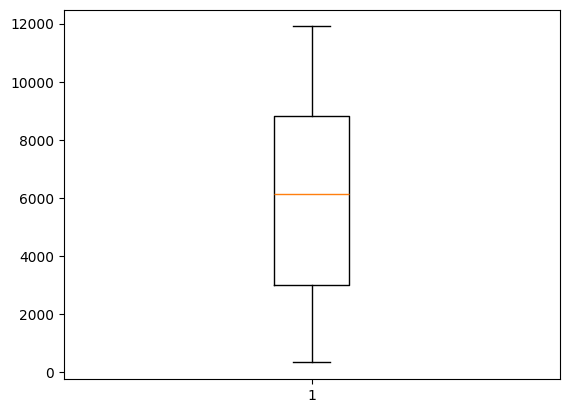

In [ ]:
plt.boxplot(df["Distance_km"])
plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

                       Ticket_ID  Distance_km  Days_Before_Departure  \
Ticket_ID               1.000000     0.075499               0.064959   
Distance_km             0.075499     1.000000              -0.036752   
Days_Before_Departure   0.064959    -0.036752               1.000000   
Price_USD               0.009621     0.642546              -0.318931   

                       Price_USD  
Ticket_ID               0.009621  
Distance_km             0.642546  
Days_Before_Departure  -0.318931  
Price_USD               1.000000  


# ***_Corrélations entre variables quantitatives***

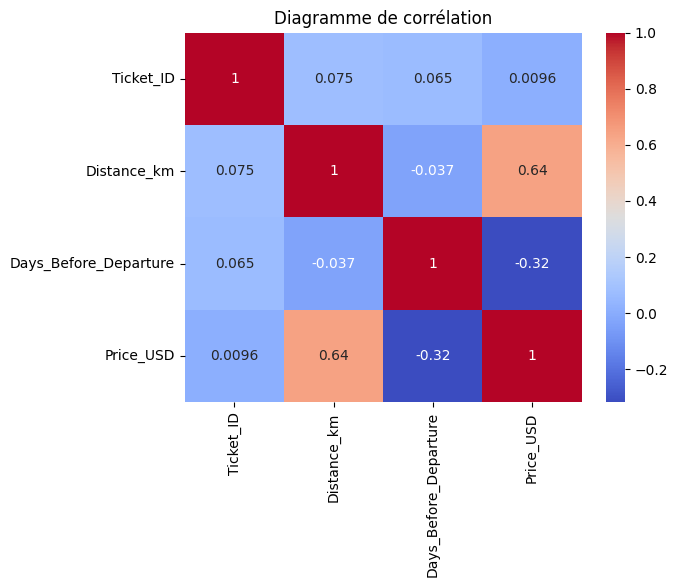


Corrélations significatives :
                        Ticket_ID  Distance_km  Days_Before_Departure  \
Ticket_ID                    NaN          NaN                    NaN   
Distance_km                  NaN          NaN                    NaN   
Days_Before_Departure        NaN          NaN                    NaN   
Price_USD                    NaN     0.642546              -0.318931   

                       Price_USD  
Ticket_ID                    NaN  
Distance_km             0.642546  
Days_Before_Departure  -0.318931  
Price_USD                    NaN  


In [ ]:
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Diagramme de corrélation")
plt.show()
significant_corr = correlation_matrix[(correlation_matrix.abs() > 0.3) & (correlation_matrix.abs() < 1)]

print("\nCorrélations significatives :\n", significant_corr)

#***_Probabilités conditionnelles et lois de probabilité***

P(Expensive | Business) = 0.49333333333333335

P(Class | Airline):
 Class             Business   Economy     First
Airline                                       
British Airways   0.277778  0.388889  0.333333
Emirates          0.218750  0.468750  0.312500
Etihad            0.458333  0.291667  0.250000
Flynas            0.346154  0.346154  0.307692
Lufthansa         0.323529  0.382353  0.294118
Qatar Airways     0.305556  0.277778  0.416667
Saudia            0.218750  0.375000  0.406250
Turkish Airlines  0.300000  0.300000  0.400000


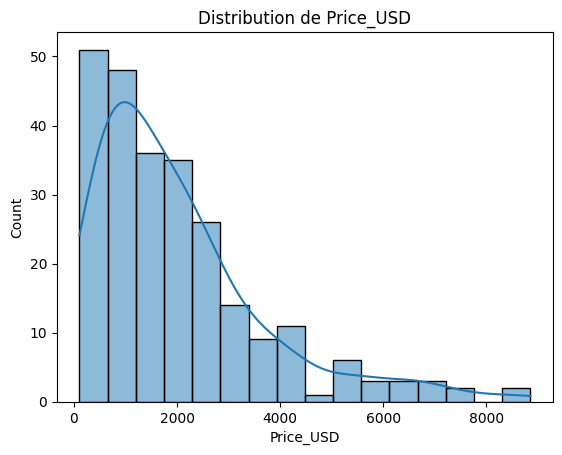


Test de normalité (Shapiro):
Stat = 0.8447023559333151
p-value = 4.036461479046268e-15
Distribution NON normale

Probabilité billet cher: 0.396
P(X=5) = 0.1972700540249396


In [ ]:
from scipy import stats
from scipy.stats import binom

threshold = df["Price_USD"].mean()
A = df["Price_USD"] > threshold
B = df["Class"] == "Business"
P_A_given_B = (A & B).sum() / B.sum()

print("P(Expensive | Business) =", P_A_given_B)

# Tableau de probabilités conditionnelles : P(Class | Airline)
prob_table = pd.crosstab(df["Airline"], df["Class"], normalize="index")
print("\nP(Class | Airline):\n", prob_table)
# 2. Test de loi normal
sns.histplot(df["Price_USD"], kde=True)
plt.title("Distribution de Price_USD")
plt.show()

# Test de normalité (Shapiro-Wilk)
stat, p_value = stats.shapiro(df["Price_USD"])

print("\nTest de normalité (Shapiro):")
print("Stat =", stat)
print("p-value =", p_value)

if p_value > 0.05:
    print("Distribution normale")
else:
    print("Distribution NON normale")
# 3. Loi binomiale
df["Expensive"] = df["Price_USD"] > threshold

# Probabilité de succès
p_binom = df["Expensive"].mean()
print("\nProbabilité billet cher:", p_binom)

# Calcul binomial : P(X = k)
n = 10
k = 5

prob_binom = binom.pmf(k, n, p_binom)
print("P(X=5) =", prob_binom)

# ***_Explication des tendances observées***

In [ ]:

# 1. Tendances globales du prix

mean_price = df["Price_USD"].mean()
median_price = df["Price_USD"].median()

print("Prix moyen :", mean_price)
print("Prix médian :", median_price)

# 2. Tendance : prix selon le nombre de jours avant départ

trend_days = df[["Days_Before_Departure", "Price_USD"]].corr()
print("\nCorrélation Days_Before_Departure vs Price:\n", trend_days)

# 3. Tendance : prix selon la durée du vol

trend_duration = df[["Distance_km", "Price_USD"]].corr()
print("\nCorrélation Distance_km vs Price:\n", trend_duration)

# 4. Tendance : prix moyen par classe

price_by_class = df.groupby("Class")["Price_USD"].mean()
print("\nPrix moyen par classe:\n", price_by_class)

# 5. Tendance : prix moyen par compagnie

price_by_airline = df.groupby("Airline")["Price_USD"].mean()
print("\nPrix moyen par compagnie:\n", price_by_airline)

Prix moyen : 2006.05976
Prix médian : 1531.2350000000001

Corrélation Days_Before_Departure vs Price:
                        Days_Before_Departure  Price_USD
Days_Before_Departure               1.000000  -0.318931
Price_USD                          -0.318931   1.000000

Corrélation Distance_km vs Price:
              Distance_km  Price_USD
Distance_km     1.000000   0.642546
Price_USD       0.642546   1.000000

Prix moyen par classe:
 Class
Business    1939.808133
Economy     1054.486292
First       3048.605233
Name: Price_USD, dtype: float64

Prix moyen par compagnie:
 Airline
British Airways     1934.800833
Emirates            2103.242813
Etihad              1486.471250
Flynas              1671.064615
Lufthansa           2066.626176
Qatar Airways       2069.334722
Saudia              2389.397500
Turkish Airlines    2140.443000
Name: Price_USD, dtype: float64


**--INTERPRETATION DES RESULTATS**
1. Prix moyen > médian → présence de valeurs élevées (outliers).

2. Corrélation Days_Before_Departure (-0.31) → plus on réserve tôt, moins le prix est cher.

3. Corrélation Distance (0.64) → plus la distance augmente, plus le prix augmente.

4. Classe → Economy < Business < First → la classe influence fortement le prix.

5. Compagnie → les prix varient selon la compagnie → influence sur le prix.

6. Conclusion → le prix dépend surtout de la distance, de la classe, du moment de réservation et de la compagnie.



**--Recommandations basées sur les données**

-Réserver les billets le plus tôt possible pour réduire les coûts.
-Privilégier la classe Economy si l’objectif est de minimiser le prix.
-Comparer les compagnies aériennes avant de réserver pour choisir la moins chère.
-Éviter les vols très longs si on cherche des billets moins chers.
-Planifier les voyages à l’avance pour profiter de meilleurs tarifs.
-Choisir la compagnie et la classe en fonction du budget disponible.